In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# se requiere instalar la librería palmerpenguins
# pip install palmerpenguins
# import palmerpenguins
# data = palmerpenguins.load_penguins()

In [10]:
# import seaborn as sns
data = sns.load_dataset("penguins") #  CARGA DEL DATASET
# Mostrar las primeras filas del DataFrame
data.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


- 'bill_length_mm' - traduce a "longitud del pico en mm"
- 'bill_depth_mm' - traduce a "profundidad del pico en mm"
- 'flipper_length_mm' - 'longitud de la aleta en mm'
- 'body_mass_g' - 'masa corporal en gramos'

In [ ]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [ ]:
# import pandas as pd
# Resaltar el valor máximo en cada columna numérica
# Seleccionamos solo las columnas numéricas para resaltar
cols_numericas = data.select_dtypes(include=['number']).columns # Retorna una lista de las columnas que son numericas
data.head(10).style.highlight_max(subset=cols_numericas, axis=0, color="#1cb511")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
5,Adelie,Torgersen,39.300000,20.600000,190.000000,3650.000000,Male
6,Adelie,Torgersen,38.900000,17.800000,181.000000,3625.000000,Female
7,Adelie,Torgersen,39.200000,19.600000,195.000000,4675.000000,Male
8,Adelie,Torgersen,34.100000,18.100000,193.000000,3475.000000,nan
9,Adelie,Torgersen,42.000000,20.200000,190.000000,4250.000000,nan


In [ ]:
# O poner barras de color según la magnitud
data.head(10).style.bar(subset=['body_mass_g'], color='#d65f5f')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100000,18.700000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.500000,17.400000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.300000,18.000000,195.000000,3250.000000,Female
3,Adelie,Torgersen,nan,nan,nan,nan,nan
4,Adelie,Torgersen,36.700000,19.300000,193.000000,3450.000000,Female
5,Adelie,Torgersen,39.300000,20.600000,190.000000,3650.000000,Male
6,Adelie,Torgersen,38.900000,17.800000,181.000000,3625.000000,Female
7,Adelie,Torgersen,39.200000,19.600000,195.000000,4675.000000,Male
8,Adelie,Torgersen,34.100000,18.100000,193.000000,3475.000000,nan
9,Adelie,Torgersen,42.000000,20.200000,190.000000,4250.000000,nan


In [ ]:
# Que tipo de datos tenemos en el DataFrame
data.dtypes # dtypes, es un metodo de los dataframes de pandas, nos devuelve una serie con el nombre de las columnas y su tipo de dato
# Las variables tipo objeto por lo general son variables categóricas, como el sexo, la especie, etc.

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [ ]:
# Cuantas variables de cada tipo tenemos
data.dtypes.value_counts()

float64    4
object     3
Name: count, dtype: int64

In [ ]:
# Cuantas variables y observaciones tenemos en el conjunto de datos (dataframe) 
data.shape # Nos devuelve una tupla con (filas, columnas)

(344, 7)

In [ ]:
# Existen valores nulos en la data?

data.isnull()  ### Importante: Devuelve un DataFrame de True / False que permite otros analisis

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [ ]:
# Permite saber si existe al menos un valor nulo en alguna columna
data.isnull().any()

In [ ]:
# Permite saber cuántos valores nulos hay en cada columna
data.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [ ]:
from IPython.display import display   #### Permite mostrar el estilo tablas de pandas en Jupyter Notebooks
# Cuales filas posee valores nulos en la data?
display(data[data.isnull().any(axis=1)]) # Indexación booleana de Pandas (no es list comprehension) (usa C internamente segun|)
print(f"Total de filas con nulos: {data.isnull().any(axis=1).sum()}")
print(f"Indices de filas con nulos: {data[data.isnull().any(axis=1)].index.tolist()}")
# Donde:
# .any(axis=1) -> Revisa fila por fila si existe al menos un valor nulo (True/False)
# .sum() -> Suma los valores True (1) para obtener el total de filas con nulos
# .tolist() -> Convierte el objeto tipo índice (de las filas con nulos) en una lista de Python

# ESTA FORMA NO ES RECOMENDABLE porque es lenta para dataframes grandes
# import numpy as np
# rows_with_nulls = [
#     row for _, row in data.iterrows()
#     if row.isnull().any()
# ]
# Donde:
# .iterrows() -> Permite iterar fila por fila en un DataFrame (lento)
# row.isnull().any() -> Revisa si en la fila existe al menos un valor nulo (True/False)



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


Total de filas con nulos: 11
Indices de filas con nulos: [3, 8, 9, 10, 11, 47, 246, 286, 324, 336, 339]
Indices de filas con nulos: Index([3, 8, 9, 10, 11, 47, 246, 286, 324, 336, 339], dtype='int64')


In [ ]:
# uso de .melt() para transformar un DataFrame de formato ancho a formato largo
# La función .melt() sirve para "des-pivotar" una tabla. (fusionar por ej dos tablas,romper la 2FN)
# En términos sencillos, convierte una tabla "ancha" (muchas columnas)
# en una tabla "larga", donde los valores se apilan en filas.
# Por tanto, es una herramienta clave en la fase de Transformación de datos (ETL),
# ya que permite normalizar estructuras que no son fáciles de analizar (en su forma ancha) o de visualizar en su formato original.
# En el formato largo:
# - Cada variable se representa en una columna
# - Cada observación o registro se representa en una fila
# Es común que el formato largo repita valores (rompa la 2ª Forma Normal),
# lo cual NO es un problema en análisis de datos.
# Este enfoque es similar a lo que hacen herramientas como Power BI,
# tablas dinámicas o motores analíticos, donde se prioriza el análisis sobre la normalización estricta de bases de datos relacionales.

data_melted = pd.melt(
    data,
    id_vars=['species', 'island'],   # columnas que se mantienen "fijas" como identificadores
    value_vars=['bill_length_mm', 'body_mass_g'],  # columnas a "apilar" (las que me interesa)
    var_name='measurement',          # nombre de la columna de variables en la cual se apilarán los nombres originales de las columnas
    value_name='value'               # nombre de la columna de valores
)
display(data_melted.head(348))
# Cuantas filas posee este nuevo DataFrame?
print(f"Total de filas en data_melted: {data_melted.shape[0]}")  # shape[0] devuelve el número de filas



,species,island,measurement,value
0,Adelie,Torgersen,bill_length_mm,39.1
1,Adelie,Torgersen,bill_length_mm,39.5
2,Adelie,Torgersen,bill_length_mm,40.3
3,Adelie,Torgersen,bill_length_mm,NaN
4,Adelie,Torgersen,bill_length_mm,36.7
...,...,...,...,...
343,Gentoo,Biscoe,bill_length_mm,49.9
344,Adelie,Torgersen,body_mass_g,3750.0
345,Adelie,Torgersen,body_mass_g,3800.0
346,Adelie,Torgersen,body_mass_g,3250.0


Total de filas en data_melted: 688


In [ ]:
# Otras formas de hacerlo, si lo me interesa body_mass_g
data[data['body_mass_g'].isnull()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


El grafico muestra la proporción de valores nulos (True) y no nulos (False) por columna. Donde la cantidad de valores nulos es muy baja en comparación con los no nulos.


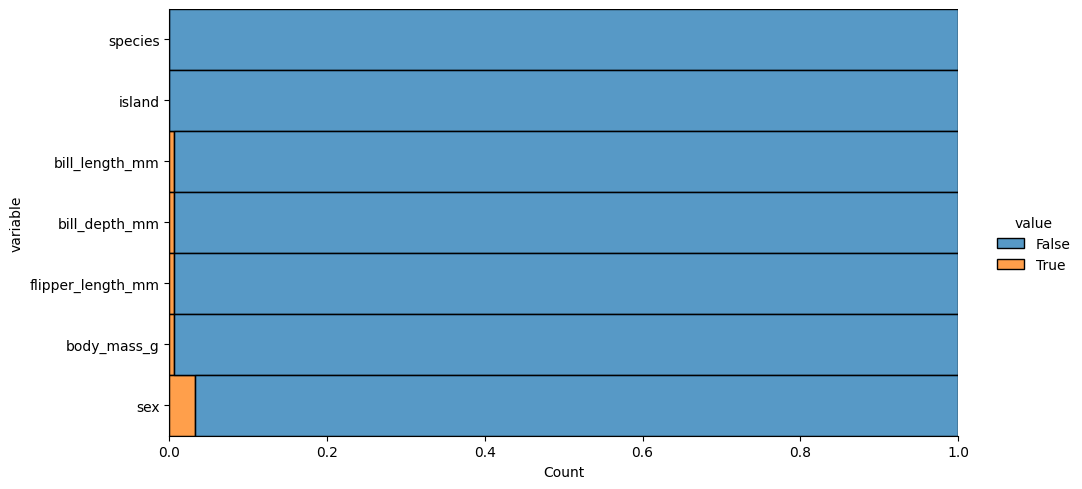

In [ ]:
(data.isnull()
.melt() # apilo todas las columnas en formato largo
.pipe(  # permite encadenar operaciones
    lambda df: (
        sns.displot(
            data = df,
            y = 'variable',
            hue = 'value',
            multiple = 'fill',
            aspect = 2,
        )
    )
)
)
print("El grafico muestra la proporción de valores nulos (True) y no nulos (False) por columna. Donde la cantidad de valores nulos es muy baja en comparación con los no nulos.")

In [ ]:
# .transpose() (.T)
# Intercambia filas por columnas y columnas por filas.
# Las columnas pasan a ser índices y los índices pasan a ser columnas.

# No modifica los datos en sí, solo cambia la orientación del DataFrame.
# Es una operación de vista / reestructuración, no de limpieza.

# Muy útil para:
# - Inspección rápida de datos
# - Visualizar muchas columnas en pocas filas
# - Comparar valores de un mismo registro
# - Analizar resultados de estadísticas (.describe(), .agg())
# REALMETNE no se usa para eliminar registros, transformar o limpiar datos como tal.
data.head(10).transpose()

,0,1,2,3,4,5,6,7,8,9
species,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie,Adelie
island,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen,Torgersen
bill_length_mm,39.1,39.5,40.3,NaN,36.7,39.3,38.9,39.2,34.1,42.0
bill_depth_mm,18.7,17.4,18.0,NaN,19.3,20.6,17.8,19.6,18.1,20.2
flipper_length_mm,181.0,186.0,195.0,NaN,193.0,190.0,181.0,195.0,193.0,190.0
body_mass_g,3750.0,3800.0,3250.0,NaN,3450.0,3650.0,3625.0,4675.0,3475.0,4250.0
sex,Male,Female,Female,NaN,Female,Male,Female,Male,NaN,NaN


In [ ]:
# Conocer estadísticos descriptivos de las columnas numéricas.
# Es visualmente más claro con .transpose() 
# Como media, mediana, desviación estándar, valores mínimos y máximos, y percentiles.
data.describe().transpose() # por defecto solo columnas numéricas
# Es posible especificar en codigo solo numeros:
# data.describe().transpose().select_dtypes(include=['number'])
# data.describe(include=['number']).transpose()

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


In [ ]:
# conocer estadísticos descriptivos de todas las columnas, tanto numéricas como categóricas.
data.describe(include='all').transpose() # Incluye todas las columnas, tanto numéricas como categóricas.
# El echo de usar .transpose() es que se ve mejor en pantalla, ya que las columnas son muchas y se pueden ver mejor en filas.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,Male,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# conocer estadísticos descriptivos de todas las columnas categóricas.
data.describe(include=object).transpose()
# conocer estadísticos descriptivos de 2 columnas categóricas específica
# data[["species", "island"]].describe()

,count,unique,top,freq
species,344,3,Adelie,152
island,344,3,Biscoe,168
sex,333,2,Male,168


In [58]:
# comocer estadísticos descriptivos de 1 columnas categórica ("species") y 1 numérica ("body_mass_g")
data[["species", "body_mass_g"]].describe(include='all').transpose()
# se requiere indicar el argumento include='all' para que incluya la columna categórica en el análisis estadístico.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0


In [62]:

# category: es un tipo de dato especializado y más eficiente que un objeto estandar de python.

# Convertir la columna "species" a tipo categórico
# data["species"] = data["species"].astype("category")

# Convertir todas las columnas de tipo objeto a categórico:
# Seleccionamos los nombres de las columnas que son tipo 'object'
columnas_objeto = data.select_dtypes(include=['object']).columns
# Las transformamos todas
data[columnas_objeto] = data[columnas_objeto].astype('category')

# otra manera
# data = data.astype({'species': 'category', 'island': 'category', 'sex': 'category'})

data.describe(include="category").transpose()

# VENTAJAS de usar category sobre object:
# Ahorro de memoria: Si tienes 10,000 filas pero solo 3 especies, category guarda el nombre una sola vez y usa números pequeños (0, 1, 2) internamente. El tipo object repite el texto completo en cada fila.
# Orden lógico: Puedes decirle a una categoría que tiene un orden (ej. ["Pequeño", "Mediano", "Grande"]), algo que el tipo objeto no entiende.
# Compatibilidad: Librerías de gráficos como Seaborn funcionan mejor cuando saben qué columnas son categóricas.


,count,unique,top,freq
species,344,3,Adelie,152
island,344,3,Biscoe,168
sex,333,2,Male,168


In [ ]:
# Validar la estructura del DataFrame en este punto del análisis
data.info()# Muestra un resumen conciso del DataFrame, incluyendo:
# - El número de entradas (filas)
# - El número de columnas
# - El nombre y tipo de dato de cada columna (Ahora es tipo category y no object)
# - El número de valores no nulos en cada columna
# - El uso de memoria del DataFrame


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   bill_length_mm     342 non-null    float64 
 3   bill_depth_mm      342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                333 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.3 KB


<Axes: >

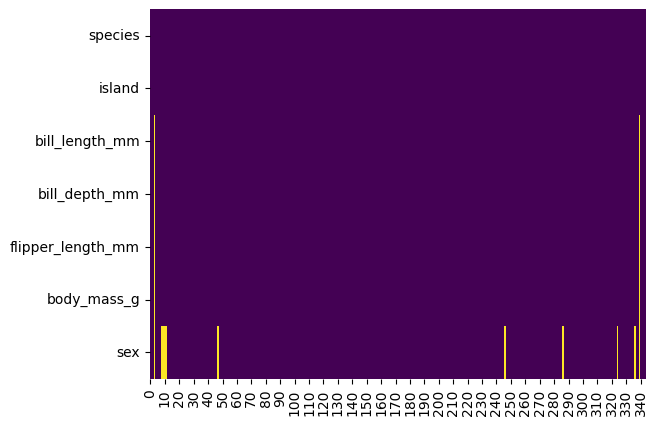

In [ ]:
# Conocer que registros tienen valores nulos en el DataFrame segun un un mapa de calor
(
    data
    .isnull()
    .transpose()
    .pipe(
        lambda df: (
            sns.heatmap(
                df,
                cbar=False, # quitar barra de colores
                cmap='viridis', # escala de colores
                # yticklabels=True, # mostrar etiquetas en eje y

            )
        )
    )

)

In [ ]:
# ELIMINAR los registros con valores nulos PERO antes reemplazar los nulos de sex por un valor como "no_definido"
# Creamos una copia profunda de los datos
data_clean = data.copy()
# Llenamos los nulos de la columna 'sex' con una nueva categoría
data_clean['sex'] = data_clean['sex'].fillna('not-defined')
#Aunque los algoritmos modernos de Machine Learning (como XGBoost) saben manejar nulos por sí solos, muchas funciones estadísticas o de gráficas ignorarán filas con null o darán error si no las manejas antes.
# 1. Eliminar si no hay medidas (los datos realmente inservibles)
# por tanto afectar variables con valores numericos como ['body_mass_g', 'bill_length_mm']
variables_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
data_clean = data_clean.dropna(subset=variables_num)
# Ahora puedes comparar ambos
print(f"Filas originales: {len(data)}")
print(f"Filas limpias: {len(data_clean)}")

Filas originales: 344
Filas limpias: 342


In [ ]:
############ Frecuencia (conteo) en VARIABLES CATEGÓRICAS #######
# “¿Cuántos pingüinos hay de cada especie?”
# Frecuencia (conteo) ¿Cuántos hay de cada categoría?
# Usaremos la variable categórica "species".
# Usaremos el método value_counts() de pandas para contar la frecuencia de cada categoría en la columna "species" del DataFrame df.
# freq = data["species"].value_counts()
freq = data.value_counts("species", sort=True) # sort=True realmente es la configuración por defecto, ordena de mayor a menor frecuencia
# mostrar el resultado
print("El resultado muestra el conteo de pingüinos por especie en el conjunto de datos.")
print("----------------")
print(freq)
print("Total de pingüinos:", freq.sum())


El resultado muestra el conteo de pingüinos por especie en el conjunto de datos.
----------------
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
Total de pingüinos: 344


In [23]:
############# Proporción 
# relación entre las partes y el todo.
#  ¿Cuál es la proporción de cada categoría respecto al total?
#¿Qué tan representativa es cada categoría respecto al total?
prop = data["species"].value_counts(normalize=True)
# prop es un objeto especial de Pandas llamado Series que permite operaciones vectorizadas.
print("El resultado muestra la proporción (en porcentaje) de pingüinos por especie en el conjunto de datos.")
print("----------------")
display(prop * 100) # En porcentaje:
# Nota: El objeto Series en esta operacion toma cada valor de la columna y lo multiplica individualmente por 100, pero mantiene las etiquetas (nombres) donde están.





El resultado muestra la proporción (en porcentaje) de pingüinos por especie en el conjunto de datos.
----------------


species
Adelie       44.186047
Gentoo       36.046512
Chinstrap    19.767442
Name: proportion, dtype: float64

# El objeto Series es exclusivo de la librería Pandas.
Una Series es básicamente una columna inteligente que tiene:
Valores: Los datos (como los porcentajes que viste).
Índice (Index): Las etiquetas o nombres de cada fila (como "Adelie", "Gentoo").
Nombre: La columna misma puede tener un nombre (como "species").
¿Por qué Pandas inventó la Series si ya existían las listas?
Por tres razones que hacen que tu código de los pingüinos funcione:
Alineación automática: Si sumas dos Series, Pandas no suma la posición 1 con la 1; busca que las etiquetas coincidan (ej. suma "Adelie" con "Adelie").
Operaciones vectorizadas: Es lo que te mencioné antes: prop * 100. En una lista normal de Python, eso fallaría o haría algo raro. En una Series, multiplica todo el bloque de datos al instante.
Métodos estadísticos: Las listas de Python no tienen un botón de .value_counts() o .mean(). Pandas creó la Series para que pudieras pedirle estadísticas con una sola palabra.

In [28]:
distribution = pd.DataFrame({
    "frecuencia": freq,
    "proporcion": prop
})
distribution["proporcion"] = distribution["proporcion"] * 100  # Proporción en porcentaje, pero no frecuencia OJO!!!
print("El resultado muestra una tabla con el conteo y la proporción (en porcentaje) de pingüinos por especie en el conjunto de datos.")
print("----------------")
display(distribution)

El resultado muestra una tabla con el conteo y la proporción (en porcentaje) de pingüinos por especie en el conjunto de datos.
----------------


,frecuencia,proporcion
species,,
Adelie,152,44.186047
Gentoo,124,36.046512
Chinstrap,68,19.767442


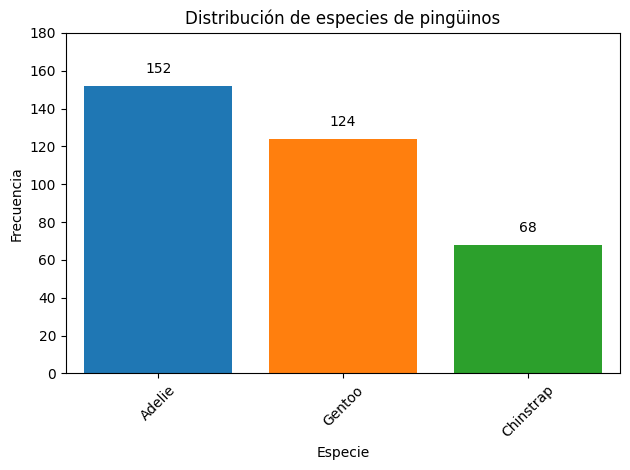

In [ ]:
# Visualización de la distribución de especies de pingüinos  (En este caso de una variable categórica)
# Usamos un gráfico de barras para mostrar la frecuencia de cada especie.
freq.plot(kind="bar")  # USO DE LA SERIE freq creada anteriormente con value_counts()
# Adicional:
plt.title("Distribución de especies de pingüinos")
plt.xlabel("Especie")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()  # Ajusta el diseño para evitar recortes
# color de barras diferentes
plt.bar(freq.index, freq.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
# colocar sobre la barra el valor de la frecuencia
for i, v in enumerate(freq):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')
# frecuencia rango de 0 a 180 
plt.ylim(0, 180)
# intervalos de 20 en 20
plt.yticks(range(0, 181,20))
# Mostrar el gráfico:
plt.show()

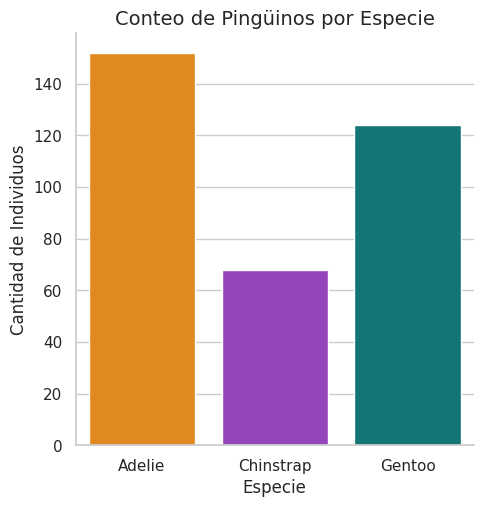

In [ ]:
#### USO DE SEABORN PARA GRAFICO DE BARRAS DE FRECUENCIAS EN VARIABLE CATEGÓRICA ######
# Gráfico de barras con Seaborn para la variable categórica "species"

# 1. Definimos la variable de colores (Paleta personalizada)
# Como Seaborn no sabe qué color quieres para cada especie, creamos un diccionario.
# Usamos colores que representen bien a los pingüinos o que sean fáciles de distinguir.
penguin_color = {
    'Adelie': '#FF8C00',    # Naranja fuerte
    'Chinstrap': '#9932CC', # Morado
    'Gentoo': '#058585'     # Verde azulado
}

# 2. Configuración estética de Seaborn (Opcional pero recomendado)
sns.set_theme(style="whitegrid") 

# 3. El gráfico catplot
sns.catplot(
    data=data,
    x='species',        # Variable categórica en el eje X
    kind='count',       # 'count' le dice a Seaborn que debe contar las filas automáticamente
    palette=penguin_color, # Aplicamos nuestra paleta manual
    hue='species',      # Añadir hue ayuda a que la paleta se asigne correctamente a cada barra
    legend=False        # Quitamos la leyenda si ya tenemos nombres en el eje X
)

# 4. Ajustes finales con Matplotlib
plt.title('Conteo de Pingüinos por Especie', size=14)
plt.xlabel('Especie', size=12)
plt.ylabel('Cantidad de Individuos', size=12)

plt.show()
# Es de acotar: que Seaborn está construida sobre Matplotlib. Cuando instalas Seaborn, obligatoriamente se instala Matplotlib porque Seaborn lo necesita para "dibujar".

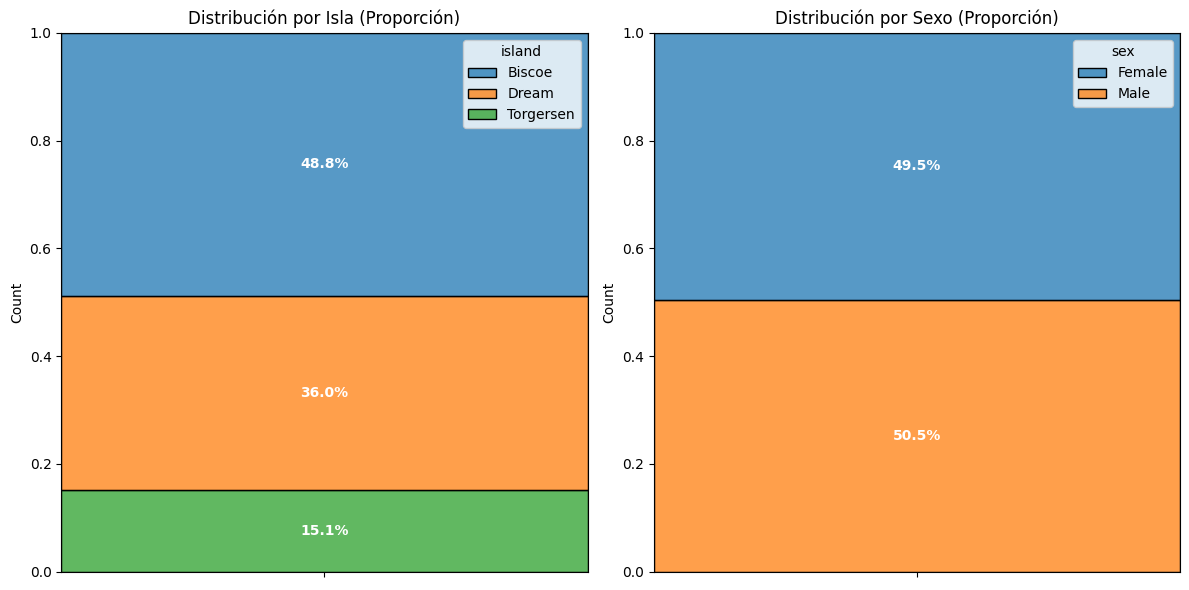

In [ ]:
##### ENTENDER ALGUN DIA ##################
# Histogramas apilados al 100% para variables categóricas:

# import matplotlib.pyplot as plt
# import seaborn as sns

# truco avanzado de un compañerp para convertir un Histograma (que es para números) en un Gráfico de Barras Apiladas al 100% (para ver proporciones de categorías)

# Función para añadir etiquetas (Explicación abajo)
def agregar_etiquetas(ax):
    for container in ax.containers:
        # Extraemos la altura de cada segmento (proporción)
        labels = [f'{v.get_height():.1%}' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, label_type='center', color='white', weight='bold')

# 1. CORRECCIÓN: Forma correcta de añadir la columna vacía
data['x'] = '' 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico 1: Proporción por Isla
sns.histplot(data=data, x='x', hue='island', multiple='fill', ax=axes[0], shrink=.8)
axes[0].set_title('Distribución por Isla (Proporción)')
axes[0].set_xlabel('') # Limpiamos el eje X
agregar_etiquetas(axes[0])

# Gráfico 2: Proporción por Sexo
sns.histplot(data=data, x='x', hue='sex', multiple='fill', ax=axes[1], shrink=.8)
axes[1].set_title('Distribución por Sexo (Proporción)')
axes[1].set_xlabel('')
agregar_etiquetas(axes[1])

plt.tight_layout()
plt.show()

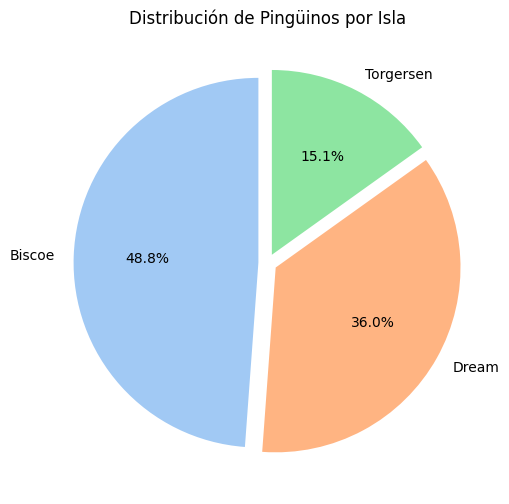

In [ ]:
##### ENTENDER ALGUN DIA ##################

# Gráfico de pastel (pie chart) para una variable categórica

# 1. Preparamos los datos
conteos = data['island'].value_counts()

# 2. Creamos el gráfico
plt.figure(figsize=(6, 6))
plt.pie(
    conteos, 
    labels = conteos.index, 
    autopct = '%1.1f%%', 
    colors = sns.color_palette('pastel'), # Opcional: colores bonitos
    startangle = 90,                     # Rota el gráfico para mejor lectura
    explode = [0.05, 0.05, 0.05]         # Separa las tajadas
)

plt.title('Distribución de Pingüinos por Isla')
plt.show()

In [ ]:
########## Moda (categoría dominante)
moda = data["species"].mode()
print(moda)
# 📌 Interpretación:
# Es la especie más frecuente
# El “líder” de la categoría
# Es util para identificar la categoría dominante en variables categóricas rapidamente.

0    Adelie
Name: species, dtype: object

In [38]:
######### Cardinalidad (diversidad de categorías)
cardinalidad = data["species"].nunique()
print("El resultado muestra el número de categorías únicas en la columna 'species'.")
print("----------------")
print(cardinalidad)
# 📌 Interpretación:
# Número de categorías únicas
# Mide diversidad, no reparto
print("El resultado muestra el número de categorías únicas en la columna 'island'.")
print("----------------")
print(data["island"].nunique())
    

El resultado muestra el número de categorías únicas en la columna 'species'.
----------------
3
El resultado muestra el número de categorías únicas en la columna 'island'.
----------------
3


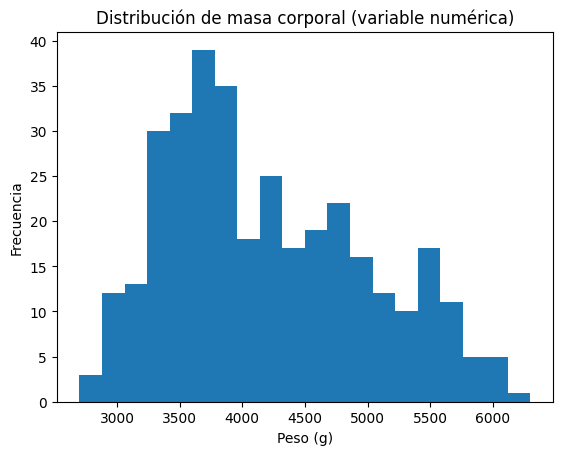

In [ ]:
####### Distribución de una variable numérica ########## 
# A diferencia de las variables categóricas, las variables numéricas tienen un rango continuo de valores.
# Para analizar su distribución, usamos histogramas en el caso de variables numéricas y en las variables categóricas se usa diagramas de barra.
# De hecho, aunque se parecen (ambos usan rectángulos), su funcionamiento interno es muy distinto (espacios entre barras, reorganizacion, etc). 
data["body_mass_g"].dropna().plot(kind="hist", bins=20)
plt.title("Distribución de masa corporal (variable numérica)")
plt.xlabel("Peso (g)")
plt.ylabel("Frecuencia")
plt.show()